In [1]:
import sys
import os 

project_root = "/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/Bachelorarbeit/Code"

sys.path.append(project_root)

In [2]:
from utils.analytics import eval_fit_methods
import networks
import estimator.stable_estimators as se
from scipy.stats import levy_stable
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import plots, optimreg
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import pandas as pd
import pickle
import numpy as np

<h1> Load MNIST Dataset </h1>

In [3]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  
])


full_train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_size = int(0.8 * len(full_train_dataset))  
val_size   = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])


batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.25MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 239kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.64MB/s]


<h1> Gaussian Network </h1>

In [40]:
optimreg.alpha_regularization(fc4_gaussian)

15.695889000000001

<h2> Pre Training </h2>

Inspect the Distribution of each layer for the gaussian initialized FC4 Network pre training 

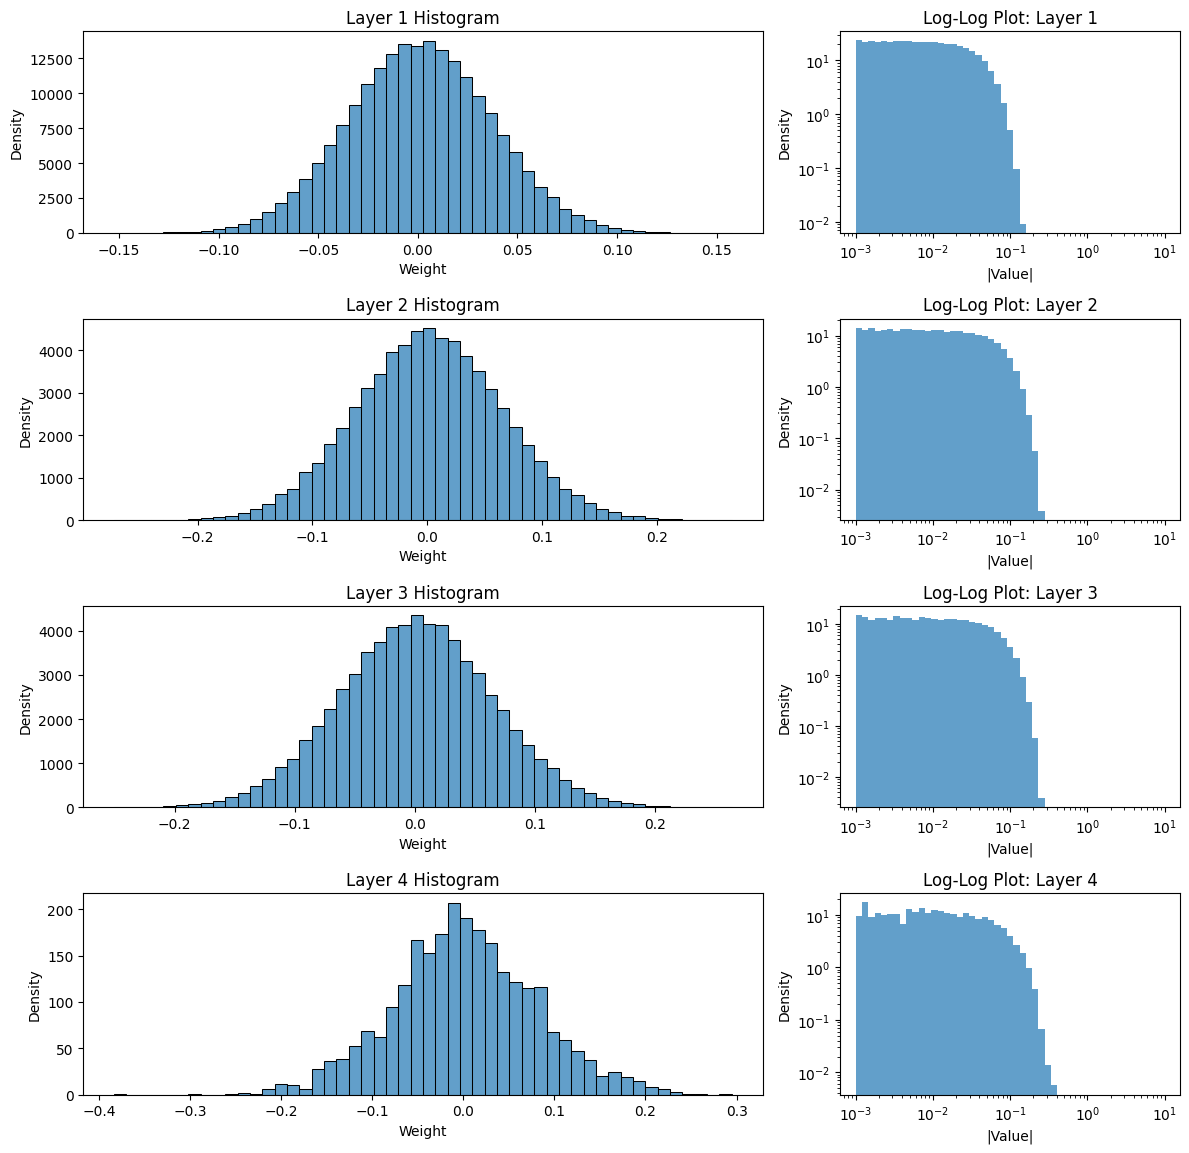

In [76]:
plots.layerwise_weight_dist(fc4_gaussian, log_log=True)

<h1> Training <h1>

<h2>Without regularizer<h2>

In [3]:
fc4_gaussian = networks.FCNet()
fc4_gaussian.to(device)


FCNet(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1-2): 2 x Linear(in_features=256, out_features=256, bias=True)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [ ]:
accuracies = []

for i in range(10): 

    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        model_name="fc10_gaussian_none_sgd",
        epochs=5,
        lambda_reg=1e-2,
        logging=True, 
        run=i
    )

    acc = networks.evaluate(model, test_loader)
    accuracies.append(acc)

    print(acc)


print(accuracies)
print(np.mean(accuracies))
print(np.std(accuracies))

Epoch 1/5, Loss: 0.3754, Accuracy: 88.07%
Epoch 2/5, Loss: 0.1242, Accuracy: 96.36%
Epoch 3/5, Loss: 0.0839, Accuracy: 97.55%
Epoch 4/5, Loss: 0.0667, Accuracy: 97.97%
Epoch 5/5, Loss: 0.0534, Accuracy: 98.39%
Test Accuracy: 97.51%
0.9751
Epoch 1/5, Loss: 0.3813, Accuracy: 88.15%
Epoch 2/5, Loss: 0.1243, Accuracy: 96.33%
Epoch 3/5, Loss: 0.0850, Accuracy: 97.48%
Epoch 4/5, Loss: 0.0677, Accuracy: 98.04%
Epoch 5/5, Loss: 0.0612, Accuracy: 98.18%
Test Accuracy: 97.11%
0.9711
Epoch 1/5, Loss: 0.3813, Accuracy: 87.60%
Epoch 2/5, Loss: 0.1215, Accuracy: 96.41%
Epoch 3/5, Loss: 0.0877, Accuracy: 97.42%
Epoch 4/5, Loss: 0.0657, Accuracy: 98.03%
Epoch 5/5, Loss: 0.0519, Accuracy: 98.47%
Test Accuracy: 97.69%
0.9769
Epoch 1/5, Loss: 0.3638, Accuracy: 88.65%
Epoch 2/5, Loss: 0.1249, Accuracy: 96.30%
Epoch 3/5, Loss: 0.0879, Accuracy: 97.38%
Epoch 4/5, Loss: 0.0641, Accuracy: 98.13%
Epoch 5/5, Loss: 0.0560, Accuracy: 98.31%
Test Accuracy: 97.43%
0.9743
Epoch 1/5, Loss: 0.3632, Accuracy: 88.55%
Ep

In [29]:
x = fc4_gaussian.layers[3].weight.detach().cpu().numpy().tolist()


<h2> ReMORe </h2>

In [3]:
lambdas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

results = []

for lbda in lambdas:

    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)
    
    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        epochs=50,
        lambda_reg=lbda,
        logging=False,
        regularizer="remore", 
   
    )
    
    acc = networks.evaluate(model, test_loader)
    
    results.append({"lambda": lbda, "accuracy": acc})

df_results = pd.DataFrame(results)
print(df_results)

import matplotlib.pyplot as plt
plt.semilogx(df_results['lambda'], df_results['accuracy'], marker='o')
plt.xlabel("Lambda")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Tuning: Alpha Regularization")
plt.grid(True)
plt.show()

KeyboardInterrupt: 

In [3]:
accuracies = []
for i in range(10): 

    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        model_name="fc10_gaussian_remore_sgd_v2",
        epochs=200,
        lambda_reg=5e-3,
        regularizer= "remore", 
        logging=True, 
        run=i
    )

    acc = networks.evaluate(model, test_loader)
    accuracies.append(acc)

    print(acc)

print(accuracies)
print(np.mean(accuracies))
print(np.std(accuracies))

Epoch 1/200, Loss: 2.3030, Accuracy: 9.62%
Epoch 2/200, Loss: 2.3022, Accuracy: 9.91%
Epoch 3/200, Loss: 2.3014, Accuracy: 12.08%
Epoch 4/200, Loss: 2.3006, Accuracy: 16.01%
Epoch 5/200, Loss: 2.2999, Accuracy: 18.92%
Epoch 6/200, Loss: 2.2991, Accuracy: 20.95%
Epoch 7/200, Loss: 2.2983, Accuracy: 21.76%
Epoch 8/200, Loss: 2.2975, Accuracy: 21.99%
Epoch 9/200, Loss: 2.2966, Accuracy: 22.63%
Epoch 10/200, Loss: 2.2957, Accuracy: 22.37%
Epoch 11/200, Loss: 2.2946, Accuracy: 22.56%
Epoch 12/200, Loss: 2.2934, Accuracy: 22.80%
Epoch 13/200, Loss: 2.2921, Accuracy: 23.41%
Epoch 14/200, Loss: 2.2907, Accuracy: 24.30%
Epoch 15/200, Loss: 2.2890, Accuracy: 25.30%
Epoch 16/200, Loss: 2.2872, Accuracy: 26.12%
Epoch 17/200, Loss: 2.2851, Accuracy: 27.25%
Epoch 18/200, Loss: 2.2828, Accuracy: 28.32%
Epoch 19/200, Loss: 2.2799, Accuracy: 29.47%
Epoch 20/200, Loss: 2.2767, Accuracy: 30.75%
Epoch 21/200, Loss: 2.2729, Accuracy: 31.53%
Epoch 22/200, Loss: 2.2683, Accuracy: 32.38%
Epoch 23/200, Loss: 2

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 53/200, Loss: 0.5409, Accuracy: 83.65%
Epoch 54/200, Loss: 0.5235, Accuracy: 84.30%
Epoch 55/200, Loss: 0.5084, Accuracy: 84.92%
Epoch 56/200, Loss: 0.4933, Accuracy: 85.35%
Epoch 57/200, Loss: 0.4810, Accuracy: 85.89%
Epoch 58/200, Loss: 0.4674, Accuracy: 86.30%
Epoch 59/200, Loss: 0.4549, Accuracy: 86.75%
Epoch 60/200, Loss: 0.4440, Accuracy: 87.12%
Epoch 61/200, Loss: 0.4329, Accuracy: 87.42%
Epoch 62/200, Loss: 0.4219, Accuracy: 87.76%
Epoch 63/200, Loss: 0.4122, Accuracy: 88.07%
Epoch 64/200, Loss: 0.4026, Accuracy: 88.33%
Epoch 65/200, Loss: 0.3931, Accuracy: 88.69%
Epoch 66/200, Loss: 0.3841, Accuracy: 88.94%
Epoch 67/200, Loss: 0.3752, Accuracy: 89.13%
Epoch 68/200, Loss: 0.3676, Accuracy: 89.42%
Epoch 69/200, Loss: 0.3595, Accuracy: 89.69%
Epoch 70/200, Loss: 0.3525, Accuracy: 89.92%
Epoch 71/200, Loss: 0.3455, Accuracy: 90.07%
Epoch 72/200, Loss: 0.3390, Accuracy: 90.25%
Epoch 73/200, Loss: 0.3330, Accuracy: 90.48%
Epoch 74/200, Loss: 0.3268, Accuracy: 90.62%
Epoch 75/2

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 183/200, Loss: 0.1064, Accuracy: 96.97%
Epoch 184/200, Loss: 0.1056, Accuracy: 96.99%
Epoch 185/200, Loss: 0.1052, Accuracy: 96.99%
Epoch 186/200, Loss: 0.1039, Accuracy: 97.02%
Epoch 187/200, Loss: 0.1033, Accuracy: 97.06%
Epoch 188/200, Loss: 0.1026, Accuracy: 97.04%
Epoch 189/200, Loss: 0.1020, Accuracy: 97.08%
Epoch 190/200, Loss: 0.1018, Accuracy: 97.08%
Epoch 191/200, Loss: 0.1005, Accuracy: 97.13%
Epoch 192/200, Loss: 0.0998, Accuracy: 97.16%
Epoch 193/200, Loss: 0.0989, Accuracy: 97.14%
Epoch 194/200, Loss: 0.0985, Accuracy: 97.20%
Epoch 195/200, Loss: 0.0981, Accuracy: 97.24%
Epoch 196/200, Loss: 0.0971, Accuracy: 97.23%
Epoch 197/200, Loss: 0.0963, Accuracy: 97.25%
Epoch 198/200, Loss: 0.0959, Accuracy: 97.26%
Epoch 199/200, Loss: 0.0954, Accuracy: 97.25%
Epoch 200/200, Loss: 0.0948, Accuracy: 97.32%
Test Accuracy: 96.14%
0.9614
Epoch 1/200, Loss: 2.3012, Accuracy: 11.35%
Epoch 2/200, Loss: 2.3002, Accuracy: 15.45%
Epoch 3/200, Loss: 2.2992, Accuracy: 21.25%
Epoch 4/200

...

Epoch 152/200, Loss: 0.1387, Accuracy: 96.06%
Epoch 153/200, Loss: 0.1376, Accuracy: 96.08%
Epoch 154/200, Loss: 0.1368, Accuracy: 96.09%


R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 155/200, Loss: 0.1357, Accuracy: 96.15%
Epoch 156/200, Loss: 0.1345, Accuracy: 96.16%
Epoch 157/200, Loss: 0.1336, Accuracy: 96.17%
Epoch 158/200, Loss: 0.1328, Accuracy: 96.22%
Epoch 159/200, Loss: 0.1317, Accuracy: 96.21%
Epoch 160/200, Loss: 0.1307, Accuracy: 96.26%
Epoch 161/200, Loss: 0.1294, Accuracy: 96.25%
Epoch 162/200, Loss: 0.1282, Accuracy: 96.29%
Epoch 163/200, Loss: 0.1275, Accuracy: 96.32%
Epoch 164/200, Loss: 0.1268, Accuracy: 96.38%
Epoch 165/200, Loss: 0.1255, Accuracy: 96.37%
Epoch 166/200, Loss: 0.1252, Accuracy: 96.42%
Epoch 167/200, Loss: 0.1238, Accuracy: 96.49%
Epoch 168/200, Loss: 0.1230, Accuracy: 96.44%
Epoch 169/200, Loss: 0.1222, Accuracy: 96.48%
Epoch 170/200, Loss: 0.1212, Accuracy: 96.55%
Epoch 171/200, Loss: 0.1202, Accuracy: 96.58%
Epoch 172/200, Loss: 0.1195, Accuracy: 96.61%
Epoch 173/200, Loss: 0.1190, Accuracy: 96.60%
Epoch 174/200, Loss: 0.1178, Accuracy: 96.62%
Epoch 175/200, Loss: 0.1173, Accuracy: 96.62%
Epoch 176/200, Loss: 0.1163, Accur

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 185/200, Loss: 0.1092, Accuracy: 96.86%
Epoch 186/200, Loss: 0.1085, Accuracy: 96.92%
Epoch 187/200, Loss: 0.1078, Accuracy: 96.93%
Epoch 188/200, Loss: 0.1075, Accuracy: 96.94%
Epoch 189/200, Loss: 0.1061, Accuracy: 96.93%
Epoch 190/200, Loss: 0.1053, Accuracy: 96.96%
Epoch 191/200, Loss: 0.1048, Accuracy: 97.00%
Epoch 192/200, Loss: 0.1041, Accuracy: 96.99%
Epoch 193/200, Loss: 0.1037, Accuracy: 97.04%
Epoch 194/200, Loss: 0.1029, Accuracy: 97.05%
Epoch 195/200, Loss: 0.1023, Accuracy: 97.02%
Epoch 196/200, Loss: 0.1020, Accuracy: 97.05%
Epoch 197/200, Loss: 0.1006, Accuracy: 97.11%
Epoch 198/200, Loss: 0.1004, Accuracy: 97.06%
Epoch 199/200, Loss: 0.1000, Accuracy: 97.14%
Epoch 200/200, Loss: 0.0987, Accuracy: 97.11%
Test Accuracy: 96.15%
0.9615
[0.9583, 0.9614, 0.9589, 0.9596, 0.9603, 0.963, 0.9574, 0.9601, 0.9602, 0.9615]
0.96007
0.0015595191566633523


<h2>Saturated Magnitude Outlier Regularizer <h2>

In [6]:
lambdas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

results = []

for lbda in lambdas:

    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)
    
    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        epochs=50,
        lambda_reg=lbda,
        logging=False,
        regularizer="smor", 
   
    )
    
    acc = networks.evaluate(model, test_loader)
    
    results.append({"lambda": lbda, "accuracy": acc})

df_results = pd.DataFrame(results)
print(df_results)

import matplotlib.pyplot as plt
plt.semilogx(df_results['lambda'], df_results['accuracy'], marker='o')
plt.xlabel("Lambda")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Tuning: Alpha Regularization")
plt.grid(True)
plt.show()

Epoch 1/50, Loss: 2.3026, Accuracy: 8.33%
Epoch 2/50, Loss: 2.3016, Accuracy: 8.77%
Epoch 3/50, Loss: 2.3006, Accuracy: 10.09%
Epoch 4/50, Loss: 2.2996, Accuracy: 13.05%
Epoch 5/50, Loss: 2.2986, Accuracy: 19.48%
Epoch 6/50, Loss: 2.2975, Accuracy: 24.56%
Epoch 7/50, Loss: 2.2965, Accuracy: 26.26%
Epoch 8/50, Loss: 2.2954, Accuracy: 26.79%
Epoch 9/50, Loss: 2.2942, Accuracy: 27.50%
Epoch 10/50, Loss: 2.2929, Accuracy: 27.68%
Epoch 11/50, Loss: 2.2916, Accuracy: 28.34%
Epoch 12/50, Loss: 2.2901, Accuracy: 28.60%
Epoch 13/50, Loss: 2.2885, Accuracy: 29.12%
Epoch 14/50, Loss: 2.2867, Accuracy: 30.46%
Epoch 15/50, Loss: 2.2847, Accuracy: 31.74%
Epoch 16/50, Loss: 2.2824, Accuracy: 33.30%
Epoch 17/50, Loss: 2.2798, Accuracy: 35.02%
Epoch 18/50, Loss: 2.2769, Accuracy: 36.89%
Epoch 19/50, Loss: 2.2735, Accuracy: 38.53%
Epoch 20/50, Loss: 2.2695, Accuracy: 40.37%
Epoch 21/50, Loss: 2.2649, Accuracy: 42.04%
Epoch 22/50, Loss: 2.2594, Accuracy: 43.43%
Epoch 23/50, Loss: 2.2528, Accuracy: 44.64%

KeyboardInterrupt: 

In [ ]:
accuracies = []
for i in range(10): 

    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        model_name="fc10_gaussian_smor_sgd",
        epochs=200,
        lambda_reg=5e-3,
        regularizer= "smor", 
        logging=True, 
        run=i
    )

    acc = networks.evaluate(model, test_loader)
    accuracies.append(acc)

    print(acc)

print(accuracies)
print(np.mean(accuracies))
print(np.std(accuracies))

<h2> Hill Regularizer </h2>

Epoch 1/5, Loss: -24.1119, Accuracy: 13.19%
Epoch 2/5, Loss: -8.1041, Accuracy: 11.24%
Epoch 3/5, Loss: -7.6836, Accuracy: 11.24%
Epoch 4/5, Loss: -17.2494, Accuracy: 11.24%
Epoch 5/5, Loss: -20.6800, Accuracy: 11.24%
Test Accuracy: 11.35%
Epoch 1/5, Loss: -23.5301, Accuracy: 13.01%
Epoch 2/5, Loss: -7.8121, Accuracy: 11.21%
Epoch 3/5, Loss: -7.4257, Accuracy: 11.24%
Epoch 4/5, Loss: -16.9587, Accuracy: 11.24%
Epoch 5/5, Loss: -20.2565, Accuracy: 11.24%
Test Accuracy: 11.35%
Epoch 1/5, Loss: -23.3516, Accuracy: 12.68%
Epoch 2/5, Loss: -7.5695, Accuracy: 11.21%
Epoch 3/5, Loss: -7.0530, Accuracy: 11.24%
Epoch 4/5, Loss: -16.7411, Accuracy: 11.24%
Epoch 5/5, Loss: -20.2785, Accuracy: 11.24%
Test Accuracy: 11.35%
Epoch 1/5, Loss: -23.5936, Accuracy: 13.16%
Epoch 2/5, Loss: -7.7950, Accuracy: 11.24%
Epoch 3/5, Loss: -7.3606, Accuracy: 11.24%
Epoch 4/5, Loss: -16.9385, Accuracy: 11.24%
Epoch 5/5, Loss: -20.4988, Accuracy: 11.24%
Test Accuracy: 11.35%
Epoch 1/5, Loss: -23.7272, Accuracy: 12.

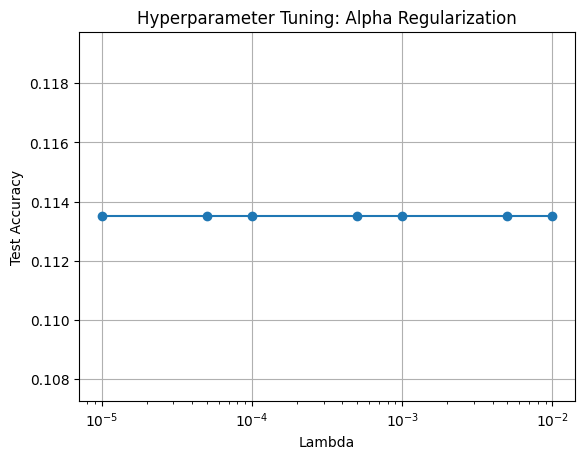

In [ ]:
lambdas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

results = []

for lbda in lambdas:

    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)
    
    optimizer = optimreg.get_optimizer(model, optimizer_name='adam', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        epochs=5,
        lambda_reg=lbda,
        logging=False,
        regularizer="hill", 
   
    )
    
    acc = networks.evaluate(model, test_loader)
    
    results.append({"lambda": lbda, "accuracy": acc})

df_results = pd.DataFrame(results)
print(df_results)

import matplotlib.pyplot as plt
plt.semilogx(df_results['lambda'], df_results['accuracy'], marker='o')
plt.xlabel("Lambda")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Tuning: Alpha Regularization")
plt.grid(True)
plt.show()

In [ ]:
for i in range(10):     
    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        model_name="fc10_gaussian_hill_sgd",
        epochs=200,
        lambda_reg=5e-5,
        logging=True,
        regularizer="hill", 
        run = i
    )

    acc = networks.evaluate(model, test_loader)

    print(acc)

Epoch 1/200, Loss: 6.7022, Accuracy: 10.13%
Epoch 2/200, Loss: 6.3712, Accuracy: 14.90%
Epoch 3/200, Loss: 6.1374, Accuracy: 17.45%
Epoch 4/200, Loss: 5.9405, Accuracy: 17.65%
Epoch 5/200, Loss: 5.7707, Accuracy: 18.38%
Epoch 6/200, Loss: 5.6211, Accuracy: 20.99%
Epoch 7/200, Loss: 5.4910, Accuracy: 22.37%
Epoch 8/200, Loss: 5.3729, Accuracy: 24.59%
Epoch 9/200, Loss: 5.2638, Accuracy: 26.52%
Epoch 10/200, Loss: 5.1679, Accuracy: 27.97%
Epoch 11/200, Loss: 5.0784, Accuracy: 28.99%
Epoch 12/200, Loss: 4.9955, Accuracy: 29.68%
Epoch 13/200, Loss: 4.9203, Accuracy: 30.53%
Epoch 14/200, Loss: 4.8498, Accuracy: 31.38%
Epoch 15/200, Loss: 4.7841, Accuracy: 31.99%
Epoch 16/200, Loss: 4.7215, Accuracy: 32.95%
Epoch 17/200, Loss: 4.6616, Accuracy: 33.60%
Epoch 18/200, Loss: 4.6048, Accuracy: 34.34%
Epoch 19/200, Loss: 4.5504, Accuracy: 35.05%
Epoch 20/200, Loss: 4.5013, Accuracy: 35.64%
Epoch 21/200, Loss: 4.4594, Accuracy: 35.96%
Epoch 22/200, Loss: 4.4268, Accuracy: 36.53%
Epoch 23/200, Loss:

In [5]:
for i in range(1):     
    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='adam', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        model_name="fc10_gaussian_hill_sum_weighted_adam",
        epochs=5,
        lambda_reg=5e-10,
        logging=True,
        regularizer="hill_weighted", 
        run = i
    )

    acc = networks.evaluate(model, test_loader)

    print(acc)

Epoch 1/5, Loss: 13.1334, Accuracy: 90.80%
Epoch 2/5, Loss: 8.2283, Accuracy: 94.50%
Epoch 3/5, Loss: 6.7962, Accuracy: 95.53%
Epoch 4/5, Loss: 5.8981, Accuracy: 96.17%
Epoch 5/5, Loss: 5.4710, Accuracy: 95.93%
Test Accuracy: 96.11%
0.9611


<h2> Lasso </h2>

Epoch 1/5, Loss: 0.3070, Accuracy: 93.28%
Epoch 2/5, Loss: 0.1699, Accuracy: 96.97%
Epoch 3/5, Loss: 0.1414, Accuracy: 97.89%
Epoch 4/5, Loss: 0.1225, Accuracy: 98.41%
Epoch 5/5, Loss: 0.1124, Accuracy: 98.63%
Test Accuracy: 97.65%
Epoch 1/5, Loss: 0.5302, Accuracy: 92.77%
Epoch 2/5, Loss: 0.3221, Accuracy: 96.61%
Epoch 3/5, Loss: 0.2566, Accuracy: 97.29%
Epoch 4/5, Loss: 0.2178, Accuracy: 97.68%
Epoch 5/5, Loss: 0.1912, Accuracy: 97.92%
Test Accuracy: 97.66%
Epoch 1/5, Loss: 0.6997, Accuracy: 92.16%
Epoch 2/5, Loss: 0.3971, Accuracy: 96.06%
Epoch 3/5, Loss: 0.3043, Accuracy: 96.89%
Epoch 4/5, Loss: 0.2588, Accuracy: 97.31%
Epoch 5/5, Loss: 0.2372, Accuracy: 97.47%
Test Accuracy: 97.03%
Epoch 1/5, Loss: 1.3181, Accuracy: 89.46%
Epoch 2/5, Loss: 0.6162, Accuracy: 93.45%
Epoch 3/5, Loss: 0.5084, Accuracy: 94.49%
Epoch 4/5, Loss: 0.4613, Accuracy: 94.91%
Epoch 5/5, Loss: 0.4334, Accuracy: 95.26%
Test Accuracy: 95.36%
Epoch 1/5, Loss: 1.6384, Accuracy: 87.66%
Epoch 2/5, Loss: 0.8029, Accur

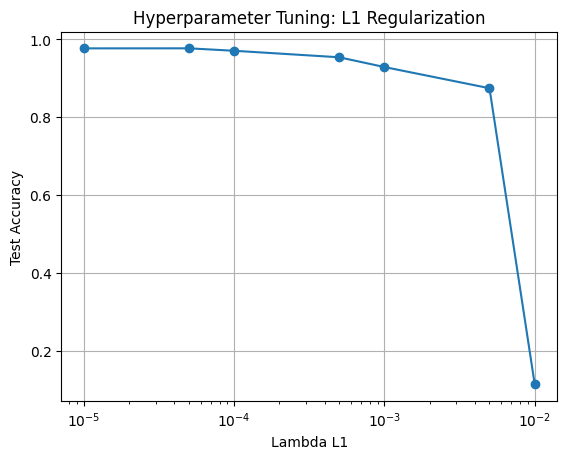

In [19]:
optimizer = optimreg.get_optimizer(fc4_gaussian_lasso, optimizer_name='adam', lr=1e-3)

lambdas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

results = []


for lambda_l1 in lambdas:

    model = networks.FCNet(layer_sizes=[784, 256, 256, 10], activation='relu', weight_init='gaussian', sigma=1.0)
    model.to(device)
    
    optimizer = optimreg.get_optimizer(model, optimizer_name='adam', lr=1e-3)

    networks.train(model, train_loader, optimizer, epochs=5, lambda_l1=lambda_l1, log_weights=False)
    
    acc = networks.evaluate(model, test_loader)
    
    results.append({"lambda_l1": lambda_l1, "accuracy": acc})

df_results = pd.DataFrame(results)
print(df_results)

# Optional: plot Accuracy vs Lambda
import matplotlib.pyplot as plt
plt.semilogx(df_results['lambda_l1'], df_results['accuracy'], marker='o')
plt.xlabel("Lambda L1")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Tuning: L1 Regularization")
plt.grid(True)
plt.show()

In [ ]:
for i in range(10):     
    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        model_name="fc10_gaussian_lasso_sgd",
        epochs=200,
        lambda_reg=1e-5,
        logging=True,
        regularizer="lasso", 
        run = i
    )

    acc = networks.evaluate(model, test_loader)

    print(acc)

Epoch 1/200, Loss: 2.6244, Accuracy: 10.85%
Epoch 2/200, Loss: 2.6231, Accuracy: 11.56%
Epoch 3/200, Loss: 2.6218, Accuracy: 12.38%
Epoch 4/200, Loss: 2.6205, Accuracy: 14.38%
Epoch 5/200, Loss: 2.6193, Accuracy: 17.29%
Epoch 6/200, Loss: 2.6182, Accuracy: 19.59%
Epoch 7/200, Loss: 2.6171, Accuracy: 21.12%
Epoch 8/200, Loss: 2.6159, Accuracy: 22.31%
Epoch 9/200, Loss: 2.6147, Accuracy: 23.14%
Epoch 10/200, Loss: 2.6134, Accuracy: 23.93%
Epoch 11/200, Loss: 2.6119, Accuracy: 24.86%
Epoch 12/200, Loss: 2.6103, Accuracy: 25.54%
Epoch 13/200, Loss: 2.6086, Accuracy: 26.58%
Epoch 14/200, Loss: 2.6067, Accuracy: 27.53%
Epoch 15/200, Loss: 2.6045, Accuracy: 28.55%
Epoch 16/200, Loss: 2.6021, Accuracy: 29.42%
Epoch 17/200, Loss: 2.5993, Accuracy: 30.21%
Epoch 18/200, Loss: 2.5962, Accuracy: 31.39%
Epoch 19/200, Loss: 2.5926, Accuracy: 32.72%
Epoch 20/200, Loss: 2.5884, Accuracy: 34.45%
Epoch 21/200, Loss: 2.5836, Accuracy: 36.58%
Epoch 22/200, Loss: 2.5778, Accuracy: 38.66%
Epoch 23/200, Loss:

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 59/200, Loss: 0.7134, Accuracy: 88.58%
Epoch 60/200, Loss: 0.7066, Accuracy: 88.79%
Epoch 61/200, Loss: 0.6992, Accuracy: 89.05%
Epoch 62/200, Loss: 0.6925, Accuracy: 89.22%
Epoch 63/200, Loss: 0.6863, Accuracy: 89.39%
Epoch 64/200, Loss: 0.6811, Accuracy: 89.59%
Epoch 65/200, Loss: 0.6746, Accuracy: 89.76%
Epoch 66/200, Loss: 0.6690, Accuracy: 89.94%
Epoch 67/200, Loss: 0.6633, Accuracy: 90.02%
Epoch 68/200, Loss: 0.6579, Accuracy: 90.26%
Epoch 69/200, Loss: 0.6528, Accuracy: 90.46%
Epoch 70/200, Loss: 0.6484, Accuracy: 90.56%
Epoch 71/200, Loss: 0.6438, Accuracy: 90.62%
Epoch 72/200, Loss: 0.6384, Accuracy: 90.73%
Epoch 73/200, Loss: 0.6340, Accuracy: 90.91%
Epoch 74/200, Loss: 0.6294, Accuracy: 91.08%
Epoch 75/200, Loss: 0.6250, Accuracy: 91.18%
Epoch 76/200, Loss: 0.6213, Accuracy: 91.29%
Epoch 77/200, Loss: 0.6176, Accuracy: 91.40%
Epoch 78/200, Loss: 0.6125, Accuracy: 91.56%
Epoch 79/200, Loss: 0.6085, Accuracy: 91.70%
Epoch 80/200, Loss: 0.6045, Accuracy: 91.75%
Epoch 81/2

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 8/200, Loss: 2.6150, Accuracy: 24.57%
Epoch 9/200, Loss: 2.6136, Accuracy: 25.50%
Epoch 10/200, Loss: 2.6120, Accuracy: 26.25%
Epoch 11/200, Loss: 2.6102, Accuracy: 27.41%
Epoch 12/200, Loss: 2.6082, Accuracy: 28.50%
Epoch 13/200, Loss: 2.6061, Accuracy: 30.01%
Epoch 14/200, Loss: 2.6036, Accuracy: 31.14%
Epoch 15/200, Loss: 2.6008, Accuracy: 32.44%
Epoch 16/200, Loss: 2.5977, Accuracy: 33.80%
Epoch 17/200, Loss: 2.5941, Accuracy: 34.91%
Epoch 18/200, Loss: 2.5898, Accuracy: 36.11%
Epoch 19/200, Loss: 2.5848, Accuracy: 36.89%
Epoch 20/200, Loss: 2.5788, Accuracy: 37.30%
Epoch 21/200, Loss: 2.5717, Accuracy: 37.58%
Epoch 22/200, Loss: 2.5629, Accuracy: 36.96%
Epoch 23/200, Loss: 2.5518, Accuracy: 36.50%
Epoch 24/200, Loss: 2.5376, Accuracy: 35.49%
Epoch 25/200, Loss: 2.5191, Accuracy: 34.71%
Epoch 26/200, Loss: 2.4949, Accuracy: 34.17%
Epoch 27/200, Loss: 2.4633, Accuracy: 33.88%
Epoch 28/200, Loss: 2.4232, Accuracy: 34.31%
Epoch 29/200, Loss: 2.3733, Accuracy: 36.23%
Epoch 30/200

...

Epoch 105/200, Loss: 0.5328, Accuracy: 93.91%
Epoch 106/200, Loss: 0.5313, Accuracy: 93.92%
Epoch 107/200, Loss: 0.5288, Accuracy: 94.01%
Epoch 108/200, Loss: 0.5261, Accuracy: 94.12%
Epoch 109/200, Loss: 0.5240, Accuracy: 94.22%
Epoch 110/200, Loss: 0.5220, Accuracy: 94.25%


R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 111/200, Loss: 0.5195, Accuracy: 94.34%
Epoch 112/200, Loss: 0.5176, Accuracy: 94.36%
Epoch 113/200, Loss: 0.5158, Accuracy: 94.46%
Epoch 114/200, Loss: 0.5140, Accuracy: 94.49%
Epoch 115/200, Loss: 0.5117, Accuracy: 94.54%
Epoch 116/200, Loss: 0.5101, Accuracy: 94.62%
Epoch 117/200, Loss: 0.5082, Accuracy: 94.65%
Epoch 118/200, Loss: 0.5065, Accuracy: 94.73%
Epoch 119/200, Loss: 0.5049, Accuracy: 94.75%
Epoch 120/200, Loss: 0.5027, Accuracy: 94.82%
Epoch 121/200, Loss: 0.5015, Accuracy: 94.85%
Epoch 122/200, Loss: 0.4993, Accuracy: 94.94%
Epoch 123/200, Loss: 0.4975, Accuracy: 94.97%
Epoch 124/200, Loss: 0.4961, Accuracy: 95.01%
Epoch 125/200, Loss: 0.4945, Accuracy: 95.06%
Epoch 126/200, Loss: 0.4932, Accuracy: 95.10%
Epoch 127/200, Loss: 0.4920, Accuracy: 95.17%
Epoch 128/200, Loss: 0.4902, Accuracy: 95.18%
Epoch 129/200, Loss: 0.4890, Accuracy: 95.23%
Epoch 130/200, Loss: 0.4870, Accuracy: 95.27%
Epoch 131/200, Loss: 0.4855, Accuracy: 95.29%
Epoch 132/200, Loss: 0.4841, Accur

R callback write-console: Fehler in if (is.na(U) | is.na(V)) { : Argument hat Länge 0
  


Epoch 156/200, Loss: 0.4560, Accuracy: 96.16%
Epoch 157/200, Loss: 0.4548, Accuracy: 96.19%
Epoch 158/200, Loss: 0.4539, Accuracy: 96.19%
Epoch 159/200, Loss: 0.4535, Accuracy: 96.21%
Epoch 160/200, Loss: 0.4522, Accuracy: 96.22%
Epoch 161/200, Loss: 0.4511, Accuracy: 96.27%
Epoch 162/200, Loss: 0.4501, Accuracy: 96.28%
Epoch 163/200, Loss: 0.4492, Accuracy: 96.32%
Epoch 164/200, Loss: 0.4488, Accuracy: 96.30%
Epoch 165/200, Loss: 0.4477, Accuracy: 96.34%
Epoch 166/200, Loss: 0.4466, Accuracy: 96.41%
Epoch 167/200, Loss: 0.4459, Accuracy: 96.39%
Epoch 168/200, Loss: 0.4452, Accuracy: 96.41%
Epoch 169/200, Loss: 0.4446, Accuracy: 96.51%
Epoch 170/200, Loss: 0.4436, Accuracy: 96.46%
Epoch 171/200, Loss: 0.4427, Accuracy: 96.53%
Epoch 172/200, Loss: 0.4418, Accuracy: 96.50%
Epoch 173/200, Loss: 0.4410, Accuracy: 96.56%
Epoch 174/200, Loss: 0.4405, Accuracy: 96.58%
Epoch 175/200, Loss: 0.4399, Accuracy: 96.61%
Epoch 176/200, Loss: 0.4391, Accuracy: 96.58%
Epoch 177/200, Loss: 0.4380, Accur

<h2> Paper Implementations </h2>

Epoch 1/10, Loss: 18.3039, Accuracy: 17.32%
Epoch 2/10, Loss: 13.5167, Accuracy: 13.43%
Epoch 3/10, Loss: 11.2716, Accuracy: 11.26%
Epoch 4/10, Loss: 9.4693, Accuracy: 11.24%
Epoch 5/10, Loss: 8.1671, Accuracy: 11.24%
Epoch 6/10, Loss: 6.9287, Accuracy: 11.24%
Epoch 7/10, Loss: 5.4351, Accuracy: 11.24%
Epoch 8/10, Loss: 4.3565, Accuracy: 11.24%
Epoch 9/10, Loss: 2.9128, Accuracy: 11.24%
Epoch 10/10, Loss: 1.7176, Accuracy: 11.24%
Test Accuracy: 11.35%
Epoch 1/10, Loss: 18.3161, Accuracy: 11.22%
Epoch 2/10, Loss: 13.5003, Accuracy: 11.24%
Epoch 3/10, Loss: 11.1669, Accuracy: 11.24%
Epoch 4/10, Loss: 9.5011, Accuracy: 11.24%
Epoch 5/10, Loss: 7.8984, Accuracy: 11.24%
Epoch 6/10, Loss: 6.8472, Accuracy: 11.24%
Epoch 7/10, Loss: 5.6950, Accuracy: 11.24%
Epoch 8/10, Loss: 4.4261, Accuracy: 11.24%
Epoch 9/10, Loss: 2.8940, Accuracy: 11.24%
Epoch 10/10, Loss: 1.6344, Accuracy: 11.24%
Test Accuracy: 11.35%
Epoch 1/10, Loss: 18.2242, Accuracy: 16.10%
Epoch 2/10, Loss: 13.4151, Accuracy: 12.30%


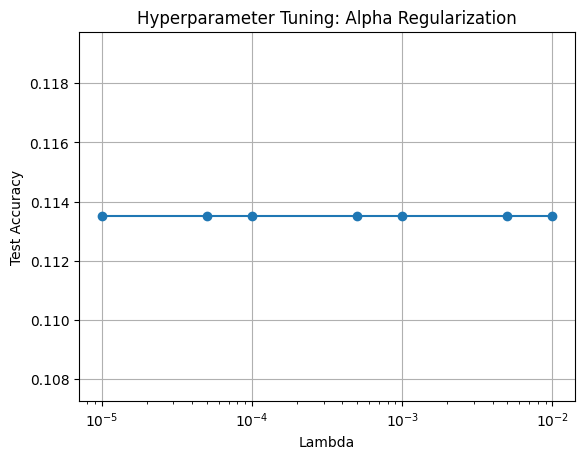

In [6]:
lambdas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

results = []

for lbda in lambdas:

    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)
    
    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        epochs=10,
        lambda_reg=lbda,
        logging=False,
        regularizer="xiao", 
   
    )
    
    acc = networks.evaluate(model, test_loader)
    
    results.append({"lambda": lbda, "accuracy": acc})

df_results = pd.DataFrame(results)
print(df_results)

import matplotlib.pyplot as plt
plt.semilogx(df_results['lambda'], df_results['accuracy'], marker='o')
plt.xlabel("Lambda")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Tuning: Alpha Regularization")
plt.grid(True)
plt.show()

In [4]:
for i in range(1):     
    model = networks.FCNet(layer_sizes=[784] + [256]*9 + [10], activation='relu', weight_init='gaussian')
    model.to(device)

    optimizer = optimreg.get_optimizer(model, optimizer_name='sgd', lr=1e-3)

    networks.train(
        model,
        train_loader,
        optimizer,
        model_name="fc10_gaussian_decay_sgd",
        epochs=200,
        lambda_reg=1e-5,
        logging=True,
        regularizer="decay", 
        run = i
    )

    acc = networks.evaluate(model, test_loader)

    print(acc)

Epoch 1/200, Loss: 18.3796, Accuracy: 13.86%
Epoch 2/200, Loss: 8.2153, Accuracy: 11.24%
Epoch 3/200, Loss: 5.7718, Accuracy: 11.24%
Epoch 4/200, Loss: 4.6756, Accuracy: 11.24%
Epoch 5/200, Loss: 4.0714, Accuracy: 11.24%
Epoch 6/200, Loss: 3.6713, Accuracy: 11.24%
Epoch 7/200, Loss: 3.4131, Accuracy: 11.24%


KeyboardInterrupt: 